In [2]:
import numpy as np
from utils.duffing import generate_duffing_data
from matplotlib import pyplot as plt

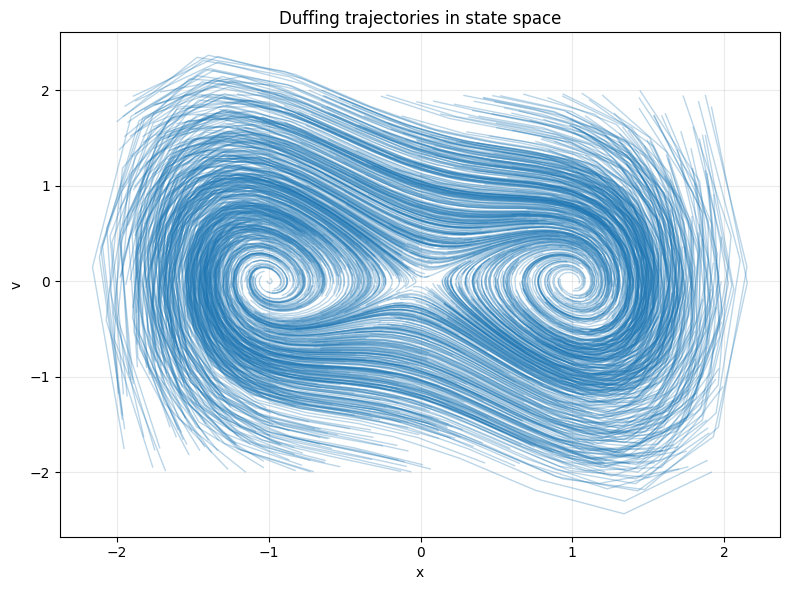

In [7]:

# Multiple trajectories: 100 random initial conditions in [-2, 2] x [-2, 2]
z0s = np.random.uniform(-2.0, 2.0, size=(1000, 2))
t, X, x, v = generate_duffing_data(z0=z0s)

fig, ax = plt.subplots(figsize=(8, 6))

for traj in X:
    ax.plot(traj[:, 0], traj[:, 1], color="tab:blue", alpha=0.3, linewidth=1)

ax.set_title("Duffing trajectories in state space")
ax.set_xlabel("x")
ax.set_ylabel("v")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [31]:
# EDMD/Koopman fit on the full Lorenz state
from utils.koopman import KoopmanEstimator

data = np.vstack([x for x in X])

koop_model = KoopmanEstimator(
    observable_type="rff",
    degree=6, # only used for polynomial observables
    include_bias=False,
    include_state=True,
    reg=1e-8,
    random_state=0,
)

# Fit K from training snapshots
koop_model.fit(data)

,observable_type,'rff'
,degree,6
,n_centers,50
,n_fourier_features,100
,gamma,None
,include_bias,False
,include_state,True
,random_state,0
,reg,1e-08


## Koopman spectral intuition

After fitting $K$, we inspect its eigendecomposition to identify dominant dynamics:
$$
K v_j = \lambda_j v_j.
$$

- $|\lambda_j|$ controls per-step growth/decay.
- $\arg(\lambda_j)$ controls oscillation.
- Continuous-time rates use $\omega_j = \log(\lambda_j)/\Delta t$.

Dynamic modes map spectral coordinates back to physical state through the decoder.
The plots below show: Koopman spectrum, leading mode components, and leading eigenfunction coordinates over time.

K matrix:
[[ 1.94451979e+01  1.64038800e+01 -3.68612636e-02 ... -2.21163329e+00
  -5.43591677e+00 -5.88192946e+00]
 [ 1.22185394e+01 -4.76296081e+01  5.25510304e-01 ...  1.44156068e+00
  -2.42772609e+00 -2.65305485e+00]
 [ 7.30218696e+01  2.51449965e+02 -3.63322139e+00 ... -1.72209668e+01
  -1.33006939e+01 -3.55114285e+00]
 ...
 [-1.51550364e+02 -3.46784706e+01 -2.16831604e+00 ...  8.91953336e+00
   1.51096389e+01  1.11072611e+01]
 [ 7.32520343e+01  3.04403908e+00  2.54508575e+00 ... -2.73464363e+00
  -7.38054064e+00 -6.24229564e+00]
 [ 9.26318398e+01  2.43718469e+02  3.52701385e+00 ... -1.73469315e+01
  -1.80473564e+01  2.91188706e+00]]

Discrete-time eigenvalues:
[ 1.00000000e+00+0.00000000e+00j  8.78770032e-01+0.00000000e+00j
  8.04536692e-01-2.11067445e-01j  8.04536692e-01+2.11067445e-01j
  6.58959817e-01-4.96367381e-01j  6.58959817e-01+4.96367381e-01j
  7.68157828e-01-2.71339645e-01j  7.68157828e-01+2.71339645e-01j
  4.14920546e-01+6.92258963e-01j  4.14920546e-01-6.92258963e-01j
 

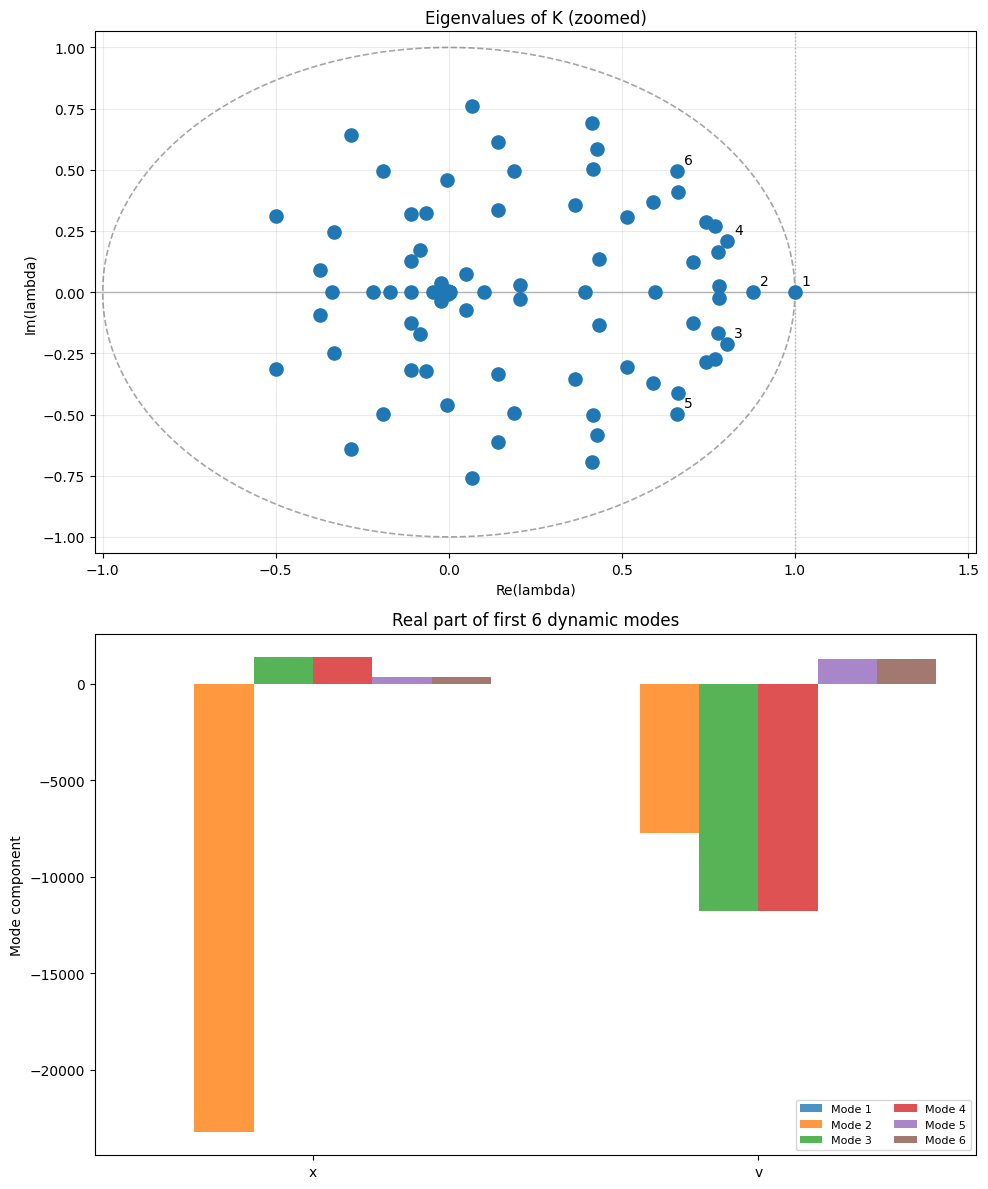

In [32]:
# Spectral analysis of K = koop_model.K_
K = koop_model.K_
eigvals, eigvecs_right = np.linalg.eig(K)
sort_idx = np.argsort(np.abs(eigvals))[::-1]
eigvals = eigvals[sort_idx]
eigvecs_right = eigvecs_right[:, sort_idx]

# Row-wise implementation: psi_{k+1} = psi_k K, with eigenfunction coordinates psi @ v_j
psi_train = koop_model._lift(data)
eigenfunction_values = psi_train @ eigvecs_right

# Decoder relation x_hat = psi B = Phi M, where M = V^{-1} B
modal_decoder = np.linalg.solve(eigvecs_right, koop_model.B_)
dynamic_modes = modal_decoder.T
continuous_eigvals = np.log(eigvals) / (t[1] - t[0])
n_modes_plot = min(6, eigvals.shape[0])

print("K matrix:")
print(np.real_if_close(K))
print()
print("Discrete-time eigenvalues:")
print(np.real_if_close(eigvals))
print()
print("Continuous-time eigenvalues:")
print(np.real_if_close(continuous_eigvals))
print()
print(f"Observable dimension: {K.shape[0]}")
print(f"State dimension: {dynamic_modes.shape[0]}")
print()
for mode_idx, lam in enumerate(eigvals[:n_modes_plot], start=1):
    mode = dynamic_modes[:, mode_idx - 1]
    print(f"Mode {mode_idx}: lambda = {lam:.6g}")
    print("  dynamic mode =", np.real_if_close(mode))

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Koopman eigenvalues in the complex plane
axes[0].scatter(eigvals.real, eigvals.imag, color="tab:blue", s=90, zorder=3)
for idx, lam in enumerate(eigvals[:n_modes_plot], start=1):
    axes[0].annotate(f"{idx}", (lam.real, lam.imag), textcoords="offset points", xytext=(5, 5))
unit_circle = np.exp(1j * np.linspace(0, 2 * np.pi, 400))
axes[0].plot(unit_circle.real, unit_circle.imag, "k--", alpha=0.35, linewidth=1.2)
axes[0].axhline(0.0, color="0.7", linewidth=1)
axes[0].axvline(1.0, color="0.7", linewidth=1, linestyle=":")
real_pad = max(1e-4, 0.35 * np.ptp(eigvals.real))
imag_pad = max(5e-4, 0.2 * np.ptp(eigvals.imag))
axes[0].set_xlim(eigvals.real.min() - real_pad, eigvals.real.max() + real_pad)
axes[0].set_ylim(eigvals.imag.min() - imag_pad, eigvals.imag.max() + imag_pad)
axes[0].grid(alpha=0.25)
axes[0].set_title("Eigenvalues of K (zoomed)")
axes[0].set_xlabel("Re(lambda)")
axes[0].set_ylabel("Im(lambda)")
axes[0].set_aspect("auto")

# Real part of leading dynamic modes in state coordinates
mode_positions = np.arange(dynamic_modes.shape[0])
bar_width = 0.8 / n_modes_plot
for idx in range(n_modes_plot):
    axes[1].bar(
        mode_positions + idx * bar_width,
        np.real(dynamic_modes[:, idx]),
        width=bar_width,
        label=f"Mode {idx + 1}",
        alpha=0.8,
    )
axes[1].set_xticks(mode_positions + 0.4 - bar_width / 2)
axes[1].set_xticklabels(["x", "v"])
axes[1].set_title(f"Real part of first {n_modes_plot} dynamic modes")
axes[1].set_ylabel("Mode component")
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

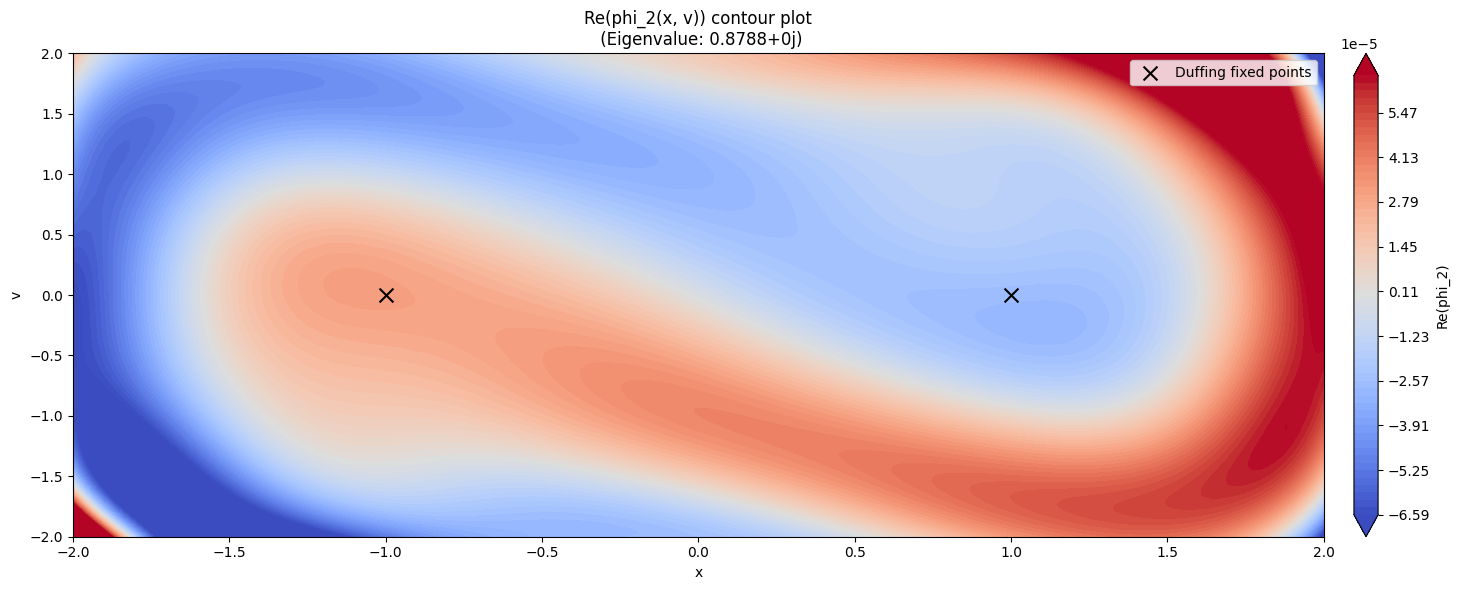

In [33]:
mode_to_plot = 1

# State-space views of one Koopman eigenfunction phi_j
mode_scores = np.std(np.real(eigenfunction_values[:, :n_modes_plot]), axis=0)
phi_label = f"phi_{mode_to_plot + 1}"
phi_train = np.real(eigenfunction_values[:, mode_to_plot])

fig = plt.figure(figsize=(16, 6))

v_min, v_max = -2, 2
x_min, x_max = -2, 2

# Grid that covers the same plotted space
grid_size = 200
v_grid = np.linspace(v_min, v_max, grid_size)
x_grid = np.linspace(x_min, x_max, grid_size)
X_grid, V_grid = np.meshgrid(x_grid, v_grid)

slice_states = np.column_stack([X_grid.ravel(), V_grid.ravel()])
psi_slice = koop_model._lift(slice_states)
phi_slice = np.real((psi_slice @ eigvecs_right)[:, mode_to_plot]).reshape(X_grid.shape)

# Color scale anchored to trajectory values (keeps phase-portrait contrast)
vmax = np.quantile(np.abs(phi_train), 0.995)
vmin = -vmax
levels = np.linspace(vmin, vmax, 60)

contours = plt.contourf(
    X_grid,
    V_grid,
    phi_slice,
    levels=levels,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    extend="both",
)

plt.scatter([-1,1], [0,0], color="k", marker="x", s=100, label="Duffing fixed points")

plt.title(f"Re({phi_label}(x, v)) contour plot\n (Eigenvalue: {eigvals[mode_to_plot]:.4g})")
plt.xlabel("x")
plt.ylabel("v")
plt.colorbar(contours, pad=0.02, label=f"Re({phi_label})")

plt.legend()

plt.tight_layout()
plt.show()


In [34]:
# Basin labels from long-time behavior of each trajectory
# For damped, unforced Duffing, trajectories settle to x ~ -1 or x ~ +1.
# We assign basin by sign of terminal x(T), then propagate that label to all points.

n_traj, n_time, _ = X.shape
basin_by_traj = np.where(X[:, -1, 0] >= 0.0, -1, 1)  # +1 right well, -1 left well
basin_labels = np.repeat(basin_by_traj, n_time)       # aligns with data = vstack([traj for traj in X])

# Eigenfunction sign on the same flattened dataset
# phi_train was computed as Re(eigenfunction_values[:, mode_to_plot]) over `data`
phi_sign = np.sign(phi_train)

# Ignore near-zero eigenfunction values to avoid unstable sign flips
eps = 1e-6
valid = np.abs(phi_train) > eps

basin_valid = basin_labels[valid]
phi_valid = phi_sign[valid]

agree = basin_valid == phi_valid
accuracy = np.mean(agree)

# 2x2 counts for (basin, eigen-sign)
count_mm = np.sum((basin_valid == -1) & (phi_valid == -1))
count_mp = np.sum((basin_valid == -1) & (phi_valid == +1))
count_pm = np.sum((basin_valid == +1) & (phi_valid == -1))
count_pp = np.sum((basin_valid == +1) & (phi_valid == +1))

print(f"Total points: {len(data):,}")
print(f"Valid points (|phi| > {eps}): {np.sum(valid):,}")
print(f"Agreement accuracy (basin vs sign(phi)): {accuracy:.3f}")
print("\nCounts (rows=basin, cols=sign(phi))")
print("            sign=-1     sign=+1")
print(f"basin=-1   {count_mm:10d} {count_mp:10d}")
print(f"basin=+1   {count_pm:10d} {count_pp:10d}")

Total points: 13,000
Valid points (|phi| > 1e-06): 12,785
Agreement accuracy (basin vs sign(phi)): 0.891

Counts (rows=basin, cols=sign(phi))
            sign=-1     sign=+1
basin=-1         5916        597
basin=+1          791       5481


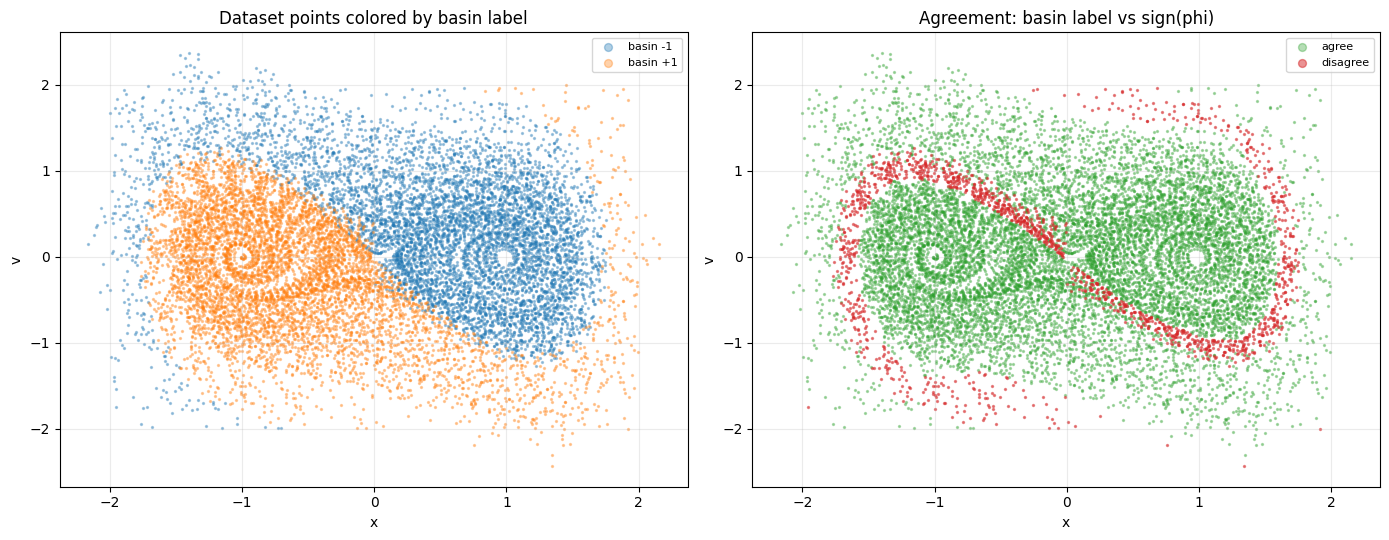

In [35]:
# Visual comparison: basin labels vs eigenfunction sign
sample = np.random.choice(len(data), size=min(120000, len(data)), replace=False)

x_s = data[sample, 0]
v_s = data[sample, 1]
basin_s = basin_labels[sample]
phi_s = phi_sign[sample]

# Green = agreement, red = disagreement
agree_s = basin_s == phi_s

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Basin labels
axes[0].scatter(x_s[basin_s < 0], v_s[basin_s < 0], s=2, alpha=0.35, label='basin -1')
axes[0].scatter(x_s[basin_s > 0], v_s[basin_s > 0], s=2, alpha=0.35, label='basin +1')
axes[0].set_title('Dataset points colored by basin label')
axes[0].set_xlabel('x')
axes[0].set_ylabel('v')
axes[0].grid(alpha=0.25)
axes[0].legend(markerscale=4, fontsize=8)

# Agreement map
axes[1].scatter(x_s[agree_s], v_s[agree_s], s=2, alpha=0.35, color='tab:green', label='agree')
axes[1].scatter(x_s[~agree_s], v_s[~agree_s], s=2, alpha=0.5, color='tab:red', label='disagree')
axes[1].set_title('Agreement: basin label vs sign(phi)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('v')
axes[1].grid(alpha=0.25)
axes[1].legend(markerscale=4, fontsize=8)

plt.tight_layout()
plt.show()